Датасет --- House Prices - Advanced Regression Techniques --- https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

1. Быстрый обзор данных

In [587]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

#тут я объединяю тренировочный и тестировочный датасеты, не сбрасывая индексы (т.к. там нормальная индексация)
df = pd.concat([train, test], axis=0, ignore_index=True)


теперь анализ датасета:

In [588]:
print("SHAPE: ", df.shape, end = "\n\n--------------------------------------\n\n")

print(df.head(10))

SHAPE:  (2919, 81)

--------------------------------------

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   
5   6          50       RL         85.0    14115   Pave   NaN      IR1   
6   7          20       RL         75.0    10084   Pave   NaN      Reg   
7   8          60       RL          NaN    10382   Pave   NaN      IR1   
8   9          50       RM         51.0     6120   Pave   NaN      Reg   
9  10         190       RL         50.0     7420   Pave   NaN      Reg   

  LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
0         Lvl    AllPub  ...        0    NaN    Na

In [589]:
print(df.tail(10))

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
2909  2910         180       RM         21.0     1470   Pave   NaN      Reg   
2910  2911         160       RM         21.0     1484   Pave   NaN      Reg   
2911  2912          20       RL         80.0    13384   Pave   NaN      Reg   
2912  2913         160       RM         21.0     1533   Pave   NaN      Reg   
2913  2914         160       RM         21.0     1526   Pave   NaN      Reg   
2914  2915         160       RM         21.0     1936   Pave   NaN      Reg   
2915  2916         160       RM         21.0     1894   Pave   NaN      Reg   
2916  2917          20       RL        160.0    20000   Pave   NaN      Reg   
2917  2918          85       RL         62.0    10441   Pave   NaN      Reg   
2918  2919          60       RL         74.0     9627   Pave   NaN      Reg   

     LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
2909         Lvl    AllPub  ...        0    NaN    N

In [590]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   str    
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   str    
 6   Alley          198 non-null    str    
 7   LotShape       2919 non-null   str    
 8   LandContour    2919 non-null   str    
 9   Utilities      2917 non-null   str    
 10  LotConfig      2919 non-null   str    
 11  LandSlope      2919 non-null   str    
 12  Neighborhood   2919 non-null   str    
 13  Condition1     2919 non-null   str    
 14  Condition2     2919 non-null   str    
 15  BldgType       2919 non-null   str    
 16  HouseStyle     2919 non-null   str    
 17  OverallQual    2919 non-null   int64  
 18  OverallCond    2919

In [591]:
print(df.describe())

                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  2919.000000  2919.000000  2433.000000    2919.000000  2919.000000   
mean   1460.000000    57.137718    69.305795   10168.114080     6.089072   
std     842.787043    42.517628    23.344905    7886.996359     1.409947   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     730.500000    20.000000    59.000000    7478.000000     5.000000   
50%    1460.000000    50.000000    68.000000    9453.000000     6.000000   
75%    2189.500000    70.000000    80.000000   11570.000000     7.000000   
max    2919.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  2919.000000  2919.000000   2919.000000  2896.000000  2918.000000  ...   
mean      5.564577  1971.312778   1984.264474   102.201312   441.423235  ...   
std       1.113131    30.291442     20.894344   179.334253   455.610826  ..

In [592]:
print(df.describe(include='object'))

       MSZoning Street Alley LotShape LandContour Utilities LotConfig  \
count      2915   2919   198     2919        2919      2917      2919   
unique        5      2     2        4           4         2         5   
top          RL   Pave  Grvl      Reg         Lvl    AllPub    Inside   
freq       2265   2907   120     1859        2622      2916      2133   

       LandSlope Neighborhood Condition1  ... GarageType GarageFinish  \
count       2919         2919       2919  ...       2762         2760   
unique         3           25          9  ...          6            3   
top          Gtl        NAmes       Norm  ...     Attchd          Unf   
freq        2778          443       2511  ...       1723         1230   

       GarageQual GarageCond PavedDrive PoolQC  Fence MiscFeature SaleType  \
count        2760       2760       2919     10    571         105     2918   
unique          5          5          3      3      4           4        9   
top            TA         TA      

/var/folders/1v/nzf1s96n6pdcm7_jy847zhjh0000gn/T/ipykernel_79201/3781773561.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


In [593]:
NaN = df.isnull().sum()
NaN = NaN.sort_values(ascending=False)[NaN != 0]
print(NaN.shape, end='\n\n\n')
print(NaN)

(35,)


PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
SalePrice       1459
FireplaceQu     1420
LotFrontage      486
GarageYrBlt      159
GarageFinish     159
GarageQual       159
GarageCond       159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
Functional         2
BsmtFullBath       2
Utilities          2
BsmtHalfBath       2
Electrical         1
TotalBsmtSF        1
BsmtUnfSF          1
KitchenQual        1
BsmtFinSF2         1
BsmtFinSF1         1
SaleType           1
GarageCars         1
Exterior2nd        1
Exterior1st        1
GarageArea         1
dtype: int64


In [594]:
print(NaN[NaN < 100].shape, end='\n\n\n')
print(NaN[NaN < 100])
fit_columns = NaN[NaN < 100].index.to_list()

(22,)


BsmtExposure    82
BsmtCond        82
BsmtQual        81
BsmtFinType2    80
BsmtFinType1    79
MasVnrArea      23
MSZoning         4
Functional       2
BsmtFullBath     2
Utilities        2
BsmtHalfBath     2
Electrical       1
TotalBsmtSF      1
BsmtUnfSF        1
KitchenQual      1
BsmtFinSF2       1
BsmtFinSF1       1
SaleType         1
GarageCars       1
Exterior2nd      1
Exterior1st      1
GarageArea       1
dtype: int64


2. Пропуски и очистка

In [595]:
''' сразу уберем все строки с пропусками, по колонкам, 
в которых менее 100 пропусков (т.к. эти выбросы незначительны и сильно не повлияют на датасет) '''

#покажем соотношение таких строк ко всем данным, чтобы доказать их незначительность

dfNaN = df[df[fit_columns].isnull().any(axis=1)]

print(f'Соотношение таких строк ко всем данным: {round((len(dfNaN)/len(df))*100, 2)}' + '%')

Соотношение таких строк ко всем данным: 4.08%


In [596]:
#теперь удалим такие строки
df = df.dropna(subset=fit_columns)
# или df = df[df[fit_columns].notnull().all(axis=1)] - мой первый вариант

#проверка
NaN = df.isnull().sum()
NaN = NaN.sort_values(ascending=False)[NaN != 0]

print(NaN.shape, end='\n\n\n')
print(NaN)

(13,)


PoolQC          2790
MiscFeature     2701
Alley           2607
Fence           2242
MasVnrType      1663
SalePrice       1388
FireplaceQu     1343
LotFrontage      465
GarageYrBlt      142
GarageFinish     142
GarageQual       142
GarageCond       142
GarageType       141
dtype: int64


In [597]:
''' теперь соберем информацию о данных в этих колонках (для удобства) '''

NaN = df.isnull().sum()
NaN = NaN.sort_values(ascending=False)[NaN != 0]
fit_columns = NaN.index

print(df[fit_columns].info())

<class 'pandas.DataFrame'>
Index: 2800 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PoolQC        10 non-null     str    
 1   MiscFeature   99 non-null     str    
 2   Alley         193 non-null    str    
 3   Fence         558 non-null    str    
 4   MasVnrType    1137 non-null   str    
 5   SalePrice     1412 non-null   float64
 6   FireplaceQu   1457 non-null   str    
 7   LotFrontage   2335 non-null   float64
 8   GarageYrBlt   2658 non-null   float64
 9   GarageFinish  2658 non-null   str    
 10  GarageQual    2658 non-null   str    
 11  GarageCond    2658 non-null   str    
 12  GarageType    2659 non-null   str    
dtypes: float64(3), str(10)
memory usage: 306.2 KB
None


In [598]:
print(df[fit_columns].describe())

           SalePrice  LotFrontage  GarageYrBlt
count    1412.000000  2335.000000  2658.000000
mean   182507.021955    69.124197  1978.315275
std     79270.416057    23.375021    25.071969
min     34900.000000    21.000000  1896.000000
25%    131475.000000    58.000000  1961.000000
50%    164600.000000    68.000000  1980.000000
75%    215000.000000    80.000000  2002.000000
max    755000.000000   313.000000  2010.000000


In [599]:
print(df[fit_columns].describe(include='object'))

       PoolQC MiscFeature Alley  Fence MasVnrType FireplaceQu GarageFinish  \
count      10          99   193    558       1137        1457         2658   
unique      3           4     2      4          3           5            3   
top        Ex        Shed  Grvl  MnPrv    BrkFace          Gd          Unf   
freq        4          90   118    322        866         721         1169   

       GarageQual GarageCond GarageType  
count        2658       2658       2659  
unique          5          5          6  
top            TA         TA     Attchd  
freq         2511       2563       1666  


/var/folders/1v/nzf1s96n6pdcm7_jy847zhjh0000gn/T/ipykernel_79201/4202640885.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df[fit_columns].describe(include='object'))


# Далее заполним оставшиеся пропуски следующим образом:

## 1) Удаление: PoolQC, MiscFeature
    - т.к. содержит малое количесвто заполненных данных, и если попытаться заполнить их каким-либо образом, то мы испортим данные
## 2) Заполнение модой: FireplaceQu (для тех строк, где Fireplaces > 0), GarageYrBlt, GarageFinish, GarageQual, GarageCond, GarageType (для тех строк, где все поля GarageArea ^ GarageCars > 0)
    - т.к. данные пропуски означают, что информация недоступна, а не отсутствует
## 3) Заполнение информации по шаблону f"No{category}": Alley, Fence, MasVnrType, FireplaceQu, GarageYrBlt, GarageFinish, GarageQual, GarageCond, GarageType
    - т.к. NaN в данном случае озачает отсутствие признака, а не отсутствие информации 
## 4) Заполнение информации медианой (median): SalePrice
    - т.к. исходя из анализа данных данной колонки (и ее важности), mean будет неприемлем в связи с большим разбросом значений и квартилями + медианой
## 5) Заполнение информации средним (mean): LotFrontage
    - т.к. исходя из анализа данных данной колонки, mean будет приемлем в связи с небольшим разбросом значений и медианой 

### 1) Удаление

In [600]:
df = df.drop(columns=['PoolQC', 'MiscFeature'])

### 2) Заполнение модой

In [601]:
print(df['Fireplaces'].value_counts())

mode = df[df['Fireplaces'] > 0]['FireplaceQu'].mode()[0]
df.loc[(df['Fireplaces'] > 0) & (df['FireplaceQu'].isnull()), 'FireplaceQu'] = mode


Fireplaces
0    1343
1    1234
2     211
3      11
4       1
Name: count, dtype: int64


In [602]:
garage_columns = ['GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageType']

print(df['GarageArea'].value_counts())
print(df['GarageCars'].value_counts())

GarageArea
0.0      141
576.0     95
440.0     95
240.0     67
484.0     65
        ... 
555.0      1
265.0      1
609.0      1
579.0      1
272.0      1
Name: count, Length: 597, dtype: int64
GarageCars
2.0    1530
1.0     746
3.0     367
0.0     141
4.0      15
5.0       1
Name: count, dtype: int64


In [603]:
# проверим зависимость этих колонок

# 1)
d_corr = df.groupby(by = 'GarageArea')['GarageCars'].count()
print(d_corr)

GarageArea
0.0       141
100.0       1
160.0       3
162.0       2
164.0       1
         ... 
1348.0      1
1356.0      1
1390.0      1
1418.0      1
1488.0      1
Name: GarageCars, Length: 597, dtype: int64


In [604]:
#2)
fig = px.scatter(df, x='GarageArea', y='GarageCars')
fig.show()

In [605]:
print(df['GarageCars'].corr(df['GarageArea']))

0.8875086259475737


In [606]:
# перейдем к заполнению с учетом того, что поля GarageArea и GarageCars не должны быть нулевыми

for column in garage_columns:
    mode = df[(df['GarageArea'] > 0) & (df['GarageCars'] > 0)][column].mode()[0]
    df.loc[(df['GarageArea'] > 0) & (df['GarageCars'] > 0) & (df[column].isnull()), column] = mode

### 3) Заполнение информации по шаблону f"No{category}"

In [607]:
columns = ['Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageType']

# уникальные случаи для 6 последних колонок из списка рассматриваются также, 
# т.к. все остальные случаи для них были рассмотрены на 2 шаге

for column in columns:
    df[column] = df[column].fillna(f'No{column}' if column != 'GarageYrBlt' else 0)

### 4) Заполнение информации медианой (median)

Кол-во not NaN:  0




/var/folders/1v/nzf1s96n6pdcm7_jy847zhjh0000gn/T/ipykernel_79201/270327626.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([d_old.dropna(), d_new],


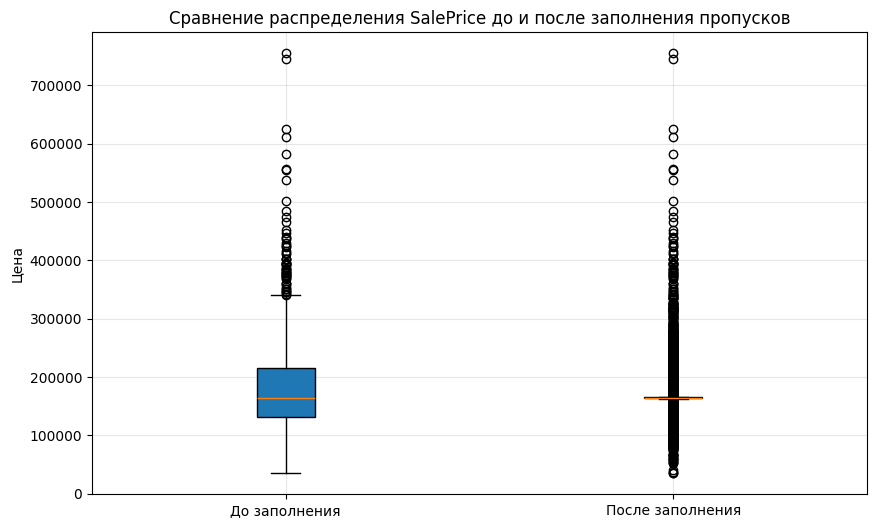

In [608]:
d_old = df['SalePrice']

df['SalePrice'] = df['SalePrice'].fillna(df['SalePrice'].median())
print("Кол-во not NaN: " , df['SalePrice'].isnull().sum(), end='\n\n\n')

d_new = df['SalePrice']

# сравним с предыдущими значениями

d = pd.DataFrame({
        'Old': d_old,
        'New': d_new,
})

plt.figure(figsize=(10, 6))
plt.boxplot([d_old.dropna(), d_new], 
            labels=['До заполнения', 'После заполнения'],
            patch_artist=True)
plt.title('Сравнение распределения SalePrice до и после заполнения пропусков')
plt.ylabel('Цена')
plt.grid(True, alpha=0.3)
plt.show()


In [609]:
# и заодно интерактивный

fig = px.box(d, y=['Old', 'New'])
fig.show()


ну тут конечно один минус в том, что мы искусственно уменьшили дисперсию, зато мы остались устойчивы к выбросам и сохранили порядок

### 5) Заполнение информации средним (mean)

Кол-во not NaN:  0


               Old          New
count  2335.000000  2800.000000
mean     69.124197    69.124197
std      23.375021    21.345237
min      21.000000    21.000000
25%      58.000000    60.000000
50%      68.000000    69.124197
75%      80.000000    79.000000
max     313.000000   313.000000


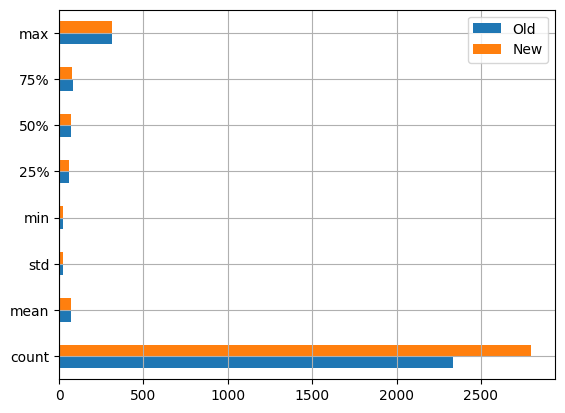

In [610]:
d_old = df['LotFrontage'].describe()

df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].mean())
print("Кол-во not NaN: " , df['LotFrontage'].isnull().sum(), end='\n\n\n')

d_new = df['LotFrontage'].describe()

# сравним с предыдущими значениями

d = pd.DataFrame({
        'Old': d_old,
        'New': d_new,
})

d.plot(kind = 'barh', grid=True)
print(d)

In [611]:
# и заодно интерактивный

fig = px.bar(d, 
             orientation='h',
             title='Сравнение статистик LotFrontage до и после заполнения пропусков',
             labels={'value': 'Значение', 'variable': 'Статистика', 'index': 'Статус'},
             barmode='group')

fig.show()

In [612]:
df.info()

<class 'pandas.DataFrame'>
Index: 2800 entries, 0 to 2918
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2800 non-null   int64  
 1   MSSubClass     2800 non-null   int64  
 2   MSZoning       2800 non-null   str    
 3   LotFrontage    2800 non-null   float64
 4   LotArea        2800 non-null   int64  
 5   Street         2800 non-null   str    
 6   Alley          2800 non-null   str    
 7   LotShape       2800 non-null   str    
 8   LandContour    2800 non-null   str    
 9   Utilities      2800 non-null   str    
 10  LotConfig      2800 non-null   str    
 11  LandSlope      2800 non-null   str    
 12  Neighborhood   2800 non-null   str    
 13  Condition1     2800 non-null   str    
 14  Condition2     2800 non-null   str    
 15  BldgType       2800 non-null   str    
 16  HouseStyle     2800 non-null   str    
 17  OverallQual    2800 non-null   int64  
 18  OverallCond    2800 non-

In [613]:
NaN = df.isnull().sum()
NaN = NaN.sort_values(ascending=False)[NaN != 0]

NaN.info()

<class 'pandas.Series'>
Index: 0 entries
Series name: None
Non-Null Count  Dtype
--------------  -----
0 non-null      int64
dtypes: int64(1)
memory usage: 0.0+ bytes


In [614]:
df_info = df.describe(include=['int64', 'float64'])

df_info.loc['5%'] = df.select_dtypes(include=['int64', 'float64']).quantile(0.05)
df_info.loc['95%'] = df.select_dtypes(include=['int64', 'float64']).quantile(0.95)
df_info.loc['mode'] = df.select_dtypes(include=['int64', 'float64']).mode().iloc[0]
df_info.loc['variance'] = df.select_dtypes(include=['int64', 'float64']).var()
df_info.loc['skewness'] = df.select_dtypes(include=['int64', 'float64']).skew()
df_info.loc['kurtosis'] = df.select_dtypes(include=['int64', 'float64']).kurt()
df_info = df_info.drop(columns=['Id'])

# переопределим порядок
new_order = ['min', '5%', '25%', '50%', 'mean', '75%', '95%', 'max', 'mode', 'variance', 'skewness', 'kurtosis', 'std']

df_info = df_info.reindex(new_order)

print(df_info)

           MSSubClass  LotFrontage       LotArea  OverallQual  OverallCond  \
min         20.000000    21.000000  1.300000e+03     1.000000     1.000000   
5%          20.000000    34.000000  3.182000e+03     4.000000     4.000000   
25%         20.000000    60.000000  7.479000e+03     5.000000     5.000000   
50%         50.000000    69.124197  9.459500e+03     6.000000     5.000000   
mean        57.367857    69.124197  1.011208e+04     6.135000     5.583929   
75%         70.000000    79.000000  1.155375e+04     7.000000     6.000000   
95%        160.000000   104.000000  1.690025e+04     8.000000     8.000000   
max        190.000000   313.000000  2.152450e+05    10.000000     9.000000   
mode        20.000000    69.124197  9.600000e+03     5.000000     5.000000   
variance  1830.511292   455.619144  6.212233e+07     1.900311     1.211246   
skewness     1.375909     1.619676  1.325747e+01     0.273361     0.664190   
kurtosis     1.418872    14.226255  2.766971e+02    -0.040923   

In [615]:
# пример для saleprice - как изменился параметр std
print(df_info['SalePrice'])

min         3.490000e+04
5%          1.084990e+05
25%         1.639675e+05
50%         1.646000e+05
mean        1.736303e+05
75%         1.650000e+05
95%         2.800000e+05
max         7.550000e+05
mode        1.646000e+05
variance    3.247905e+09
skewness    3.026913e+00
kurtosis    1.689835e+01
std         5.699040e+04
Name: SalePrice, dtype: float64


1) Дисперсия - средний квадрат отклонения от среднего. Показывает насколько данные разбросаны относительно среднего. Если дисперсия большая, то данные размазаны, если малая - то сжаты.

2) Асимметрия - показывает, насколько данные распределены симмертично относительно среднего. Принимает значения меньше нуля (если есть слишком малые значения, тянущие среднее вниз относительно медианы), ноль (если медиана и среднее совпадают) и больше нуля (если есть слишком большие значения, тянущие среднее вверх относительно медианы)

3) Эксцесс - показатель того, насколько сильные (или тяжелые) выбросы (или экстремальные значения) в нашем наборе данных по сравнению с нормальным распределением Гаусса:
- **kurtosis > 0 (лептокуртическое)**: выбросы встречаются чаще
- **kurtosis ≈ 0 (мезокуртическое)**: как у нормального распределения  
- **kurtosis < 0 (платикуртическое)**: выбросов меньше нормы

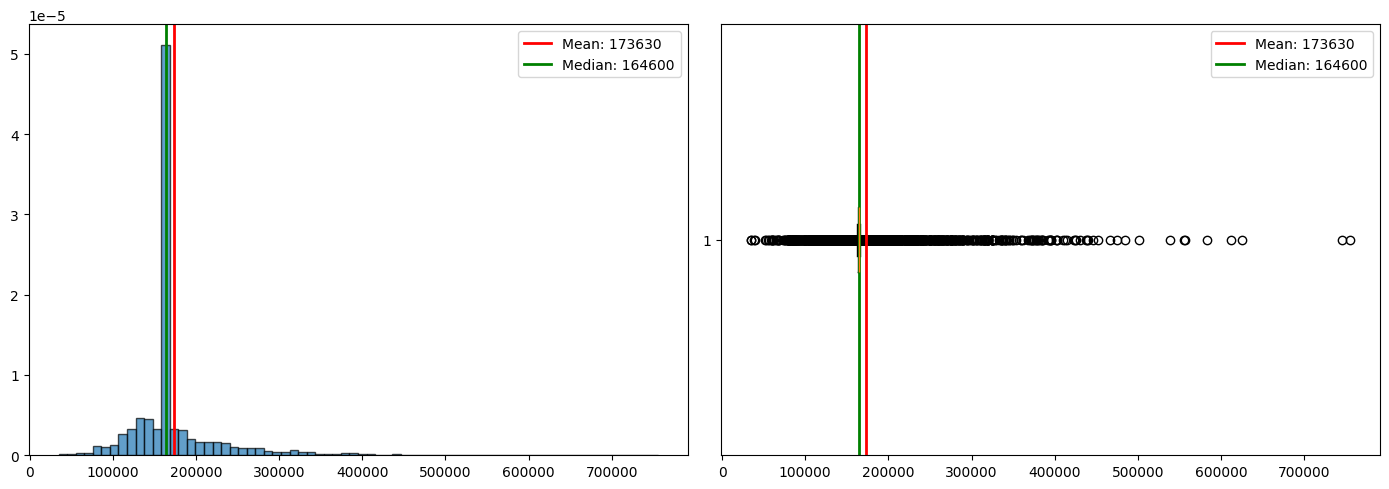

In [616]:
# пример для SalePrice

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# hist
axes[0].hist(df['SalePrice'], bins=70, density=True, alpha=0.7, edgecolor='black')
axes[0].axvline(df['SalePrice'].mean(), color='red', linewidth=2, label=f'Mean: {df["SalePrice"].mean():.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linewidth=2, label=f'Median: {df["SalePrice"].median():.0f}')
axes[0].legend()

# box
axes[1].boxplot(df['SalePrice'], vert=False)
axes[1].axvline(df['SalePrice'].mean(), color='red', linewidth=2, label=f'Mean: {df["SalePrice"].mean():.0f}')
axes[1].axvline(df['SalePrice'].median(), color='green', linewidth=2, label=f'Median: {df["SalePrice"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()


Как видно из диаграмм (среднее правее, чем медианана на 1 графике, правый ус больше левого на 2), асимметрия будет положительна, и также будет положительный эксцесс, т.к. есть сильные выбросы.

In [617]:
# проверим догадку

print(df_info['SalePrice'][['skewness', 'kurtosis']])

skewness     3.026913
kurtosis    16.898348
Name: SalePrice, dtype: float64


# D) Фичи: Энкодинг и Инжиниринг

In [618]:
# выведем данные о нашем датафрейме еще раз

df.info()

<class 'pandas.DataFrame'>
Index: 2800 entries, 0 to 2918
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2800 non-null   int64  
 1   MSSubClass     2800 non-null   int64  
 2   MSZoning       2800 non-null   str    
 3   LotFrontage    2800 non-null   float64
 4   LotArea        2800 non-null   int64  
 5   Street         2800 non-null   str    
 6   Alley          2800 non-null   str    
 7   LotShape       2800 non-null   str    
 8   LandContour    2800 non-null   str    
 9   Utilities      2800 non-null   str    
 10  LotConfig      2800 non-null   str    
 11  LandSlope      2800 non-null   str    
 12  Neighborhood   2800 non-null   str    
 13  Condition1     2800 non-null   str    
 14  Condition2     2800 non-null   str    
 15  BldgType       2800 non-null   str    
 16  HouseStyle     2800 non-null   str    
 17  OverallQual    2800 non-null   int64  
 18  OverallCond    2800 non-

In [619]:
print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street    Alley LotShape  \
0   1          60       RL         65.0     8450   Pave  NoAlley      Reg   
1   2          20       RL         80.0     9600   Pave  NoAlley      Reg   
2   3          60       RL         68.0    11250   Pave  NoAlley      IR1   
3   4          70       RL         60.0     9550   Pave  NoAlley      IR1   
4   5          60       RL         84.0    14260   Pave  NoAlley      IR1   

  LandContour Utilities  ... 3SsnPorch ScreenPorch PoolArea    Fence MiscVal  \
0         Lvl    AllPub  ...         0           0        0  NoFence       0   
1         Lvl    AllPub  ...         0           0        0  NoFence       0   
2         Lvl    AllPub  ...         0           0        0  NoFence       0   
3         Lvl    AllPub  ...         0           0        0  NoFence       0   
4         Lvl    AllPub  ...         0           0        0  NoFence       0   

  MoSold YrSold  SaleType  SaleCondition  SalePrice  
0 

## 1) MSZoning

In [620]:
print(df['MSZoning'].value_counts())

MSZoning
RL         2176
RM          447
FV          131
RH           24
C (all)      22
Name: count, dtype: int64


**Используем OneHotEncoder для MSZoning**

In [621]:
df = pd.get_dummies(df, columns=['MSZoning'], prefix='MSZoning', drop_first=True)

df.info()

<class 'pandas.DataFrame'>
Index: 2800 entries, 0 to 2918
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2800 non-null   int64  
 1   MSSubClass     2800 non-null   int64  
 2   LotFrontage    2800 non-null   float64
 3   LotArea        2800 non-null   int64  
 4   Street         2800 non-null   str    
 5   Alley          2800 non-null   str    
 6   LotShape       2800 non-null   str    
 7   LandContour    2800 non-null   str    
 8   Utilities      2800 non-null   str    
 9   LotConfig      2800 non-null   str    
 10  LandSlope      2800 non-null   str    
 11  Neighborhood   2800 non-null   str    
 12  Condition1     2800 non-null   str    
 13  Condition2     2800 non-null   str    
 14  BldgType       2800 non-null   str    
 15  HouseStyle     2800 non-null   str    
 16  OverallQual    2800 non-null   int64  
 17  OverallCond    2800 non-null   int64  
 18  YearBuilt      2800 non-

In [622]:
print(df.head()[df.columns[77:]])

   SalePrice  MSZoning_FV  MSZoning_RH  MSZoning_RL  MSZoning_RM
0   208500.0        False        False         True        False
1   181500.0        False        False         True        False
2   223500.0        False        False         True        False
3   140000.0        False        False         True        False
4   250000.0        False        False         True        False


**Используем Label для LotShape, т.к. тут присутствует порядок категорий**

In [623]:
print(df['LotShape'].value_counts())

LotShape
Reg    1769
IR1     942
IR2      73
IR3      16
Name: count, dtype: int64


In [624]:
def encode_LotShape(value: str) -> int:
    values = {'Reg': 0, 'IR1': 1, 'IR2': 2, 'IR3': 3}
    return values[value]

df['LotShape'] = df['LotShape'].apply(encode_LotShape)

df.info()   

<class 'pandas.DataFrame'>
Index: 2800 entries, 0 to 2918
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2800 non-null   int64  
 1   MSSubClass     2800 non-null   int64  
 2   LotFrontage    2800 non-null   float64
 3   LotArea        2800 non-null   int64  
 4   Street         2800 non-null   str    
 5   Alley          2800 non-null   str    
 6   LotShape       2800 non-null   int64  
 7   LandContour    2800 non-null   str    
 8   Utilities      2800 non-null   str    
 9   LotConfig      2800 non-null   str    
 10  LandSlope      2800 non-null   str    
 11  Neighborhood   2800 non-null   str    
 12  Condition1     2800 non-null   str    
 13  Condition2     2800 non-null   str    
 14  BldgType       2800 non-null   str    
 15  HouseStyle     2800 non-null   str    
 16  OverallQual    2800 non-null   int64  
 17  OverallCond    2800 non-null   int64  
 18  YearBuilt      2800 non-

In [625]:
print(df.head())

   Id  MSSubClass  LotFrontage  LotArea Street    Alley  LotShape LandContour  \
0   1          60         65.0     8450   Pave  NoAlley         0         Lvl   
1   2          20         80.0     9600   Pave  NoAlley         0         Lvl   
2   3          60         68.0    11250   Pave  NoAlley         1         Lvl   
3   4          70         60.0     9550   Pave  NoAlley         1         Lvl   
4   5          60         84.0    14260   Pave  NoAlley         1         Lvl   

  Utilities LotConfig  ... MiscVal MoSold YrSold SaleType SaleCondition  \
0    AllPub    Inside  ...       0      2   2008       WD        Normal   
1    AllPub       FR2  ...       0      5   2007       WD        Normal   
2    AllPub    Inside  ...       0      9   2008       WD        Normal   
3    AllPub    Corner  ...       0      2   2006       WD       Abnorml   
4    AllPub       FR2  ...       0     12   2008       WD        Normal   

  SalePrice  MSZoning_FV  MSZoning_RH  MSZoning_RL  MSZoning_R

In [626]:
dtype_object_columns = df.select_dtypes(include='object').columns.to_list()
unique_counts = df[dtype_object_columns].nunique().sort_values()
print(unique_counts)

def print_unique(eq: int) -> None:
    unique_eq = unique_counts[unique_counts == eq].index.to_list()

    for column in unique_eq:
        print(f'{column}: {', '.join(df[column].value_counts().index.to_list())}')

Street            2
Utilities         2
CentralAir        2
Alley             3
PavedDrive        3
LandSlope         3
GarageFinish      4
KitchenQual       4
Heating           4
BsmtExposure      4
BsmtCond          4
ExterQual         4
MasVnrType        4
BsmtQual          4
LandContour       4
ExterCond         5
Foundation        5
Fence             5
Electrical        5
BldgType          5
LotConfig         5
HeatingQC         5
SaleCondition     6
FireplaceQu       6
GarageCond        6
BsmtFinType2      6
BsmtFinType1      6
RoofStyle         6
GarageQual        6
Functional        7
GarageType        7
HouseStyle        8
RoofMatl          8
Condition2        8
Condition1        9
SaleType          9
Exterior1st      15
Exterior2nd      16
Neighborhood     25
dtype: int64


/var/folders/1v/nzf1s96n6pdcm7_jy847zhjh0000gn/T/ipykernel_79201/3767407457.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dtype_object_columns = df.select_dtypes(include='object').columns.to_list()


**2 признакa:**

In [627]:
print_unique(2)

Street: Pave, Grvl
Utilities: AllPub, NoSeWa
CentralAir: Y, N


In [628]:
# на будущее: проверка корелляции
df_corr = df.groupby(by=['Alley'])['Street'].value_counts()

print(df_corr)

Alley    Street
Grvl     Pave       118
NoAlley  Pave      2596
         Grvl        11
Pave     Pave        75
Name: count, dtype: int64


1) Street - One-Hot encoding
2) Utilities, CentralAir - label (0/1)

In [629]:
df = pd.get_dummies(df, columns=['Street'], prefix='Street', drop_first=True)

df['Utilities'] = df['Utilities'].map({'AllPub': 1, 'NoSeWa':0})
df['CentralAir'] = df['CentralAir'].map({'Y': 1, 'N':0})

**3 признака:**

In [630]:
print_unique(3)

Alley: NoAlley, Grvl, Pave
PavedDrive: Y, N, P
LandSlope: Gtl, Mod, Sev


- Alley - One-Hot encoding
- PavedDrive, LandSlope - label (0/1/2):
1) PavedDrive: Y - 2, N - 0, P - 1
2) LandSlope - Gtl - 0, Mod - 1, Sev - 2

In [631]:
df= pd.get_dummies(df, columns=['Alley'], prefix='Alley', drop_first=True)

df['PavedDrive'] = df['PavedDrive'].map({'Y': 2, 'N': 0, 'P': 1})
df['LandSlope'] = df['LandSlope'].map({'Gtl': 0, 'Mod': 1, 'Sev': 2})

**4 признака:**

In [632]:
print_unique(4)

GarageFinish: Unf, RFn, Fin, NoGarageFinish
KitchenQual: TA, Gd, Ex, Fa
Heating: GasA, GasW, Grav, OthW
BsmtExposure: No, Av, Gd, Mn
BsmtCond: TA, Gd, Fa, Po
ExterQual: TA, Gd, Ex, Fa
MasVnrType: NoMasVnrType, BrkFace, Stone, BrkCmn
BsmtQual: TA, Gd, Ex, Fa
LandContour: Lvl, HLS, Bnk, Low


- GarageFinish - label
- KitchenQual - label
- Heating - one-hot
- BsmtExposure - label
- BsmtCond - label
- ExterQual - label
- MasVnrType - one-hot
- BsmtQual - label
- LandContour - one-hot

In [633]:
df = pd.get_dummies(df, columns=['Heating', 'MasVnrType', 'LandContour'], 
                    prefix=['Heating', 'MasVnrType', 'LandContour'], drop_first=True)


quality_order = {'Po': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4}

df['KitchenQual'] = df['KitchenQual'].map(quality_order)
df['ExterQual'] = df['ExterQual'].map(quality_order)
df['BsmtQual'] = df['BsmtQual'].map(quality_order)
df['BsmtCond'] = df['BsmtCond'].map(quality_order)

bsmt_exp_order = {'No': 0, 'Mn': 1, 'Av': 2, 'Gd': 3}
df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_exp_order)

garage_finish_order = {'Unf': 0, 'RFn': 1, 'Fin': 2, 'NoGarageFinish': -1}
df['GarageFinish'] = df['GarageFinish'].map(garage_finish_order)

**5 признаков**

In [634]:
print_unique(5)

ExterCond: TA, Gd, Fa, Ex, Po
Foundation: PConc, CBlock, BrkTil, Stone, Wood
Fence: NoFence, MnPrv, GdPrv, GdWo, MnWw
Electrical: SBrkr, FuseA, FuseF, FuseP, Mix
BldgType: 1Fam, TwnhsE, Twnhs, Duplex, 2fmCon
LotConfig: Inside, Corner, CulDSac, FR2, FR3
HeatingQC: Ex, TA, Gd, Fa, Po


In [635]:
df['ExterCond'] = df['ExterCond'].map(quality_order)
df['HeatingQC'] = df['HeatingQC'].map(quality_order)

one_hot_cols = ['Foundation', 'Fence', 'Electrical', 'BldgType', 'LotConfig']

df = pd.get_dummies(df, columns=one_hot_cols, prefix=one_hot_cols, drop_first=True)

**6 признаков**

In [636]:
print_unique(6)

SaleCondition: Normal, Partial, Abnorml, Family, Alloca, AdjLand
FireplaceQu: NoFireplaceQu, Gd, TA, Fa, Po, Ex
GarageCond: TA, NoGarageCond, Fa, Gd, Po, Ex
BsmtFinType2: Unf, Rec, LwQ, BLQ, ALQ, GLQ
BsmtFinType1: GLQ, Unf, ALQ, Rec, BLQ, LwQ
RoofStyle: Gable, Hip, Gambrel, Flat, Mansard, Shed
GarageQual: TA, NoGarageQual, Fa, Gd, Po, Ex


In [637]:
df['FireplaceQu'] = df['FireplaceQu'].map(quality_order | {'NoFireplaceQu': -1})
df['GarageCond'] = df['GarageCond'].map(quality_order | {'NoGarageCond': -1})
df['GarageQual'] = df['GarageQual'].map(quality_order | {'NoGarageQual': -1})

bsmt_finish_order = {'Unf': 0, 'LwQ': 1, 'Rec': 2, 'BLQ': 3, 'ALQ': 4, 'GLQ': 5}
df['BsmtFinType1'] = df['BsmtFinType1'].map(quality_order | {'NoGarageCond': -1})
df['BsmtFinType2'] = df['BsmtFinType2'].map(quality_order | {'NoGarageQual': -1})

df = pd.get_dummies(df, columns=['RoofStyle'], prefix='RoofStyle', drop_first=True)

- Использую target encoding для SaleCondition

In [638]:
target_means = df.groupby('SaleCondition')['SalePrice'].mean()

df['SaleCondition'] = df['SaleCondition'].map(target_means)

**7 признаков**

In [639]:
print_unique(7)

Functional: Typ, Min2, Min1, Mod, Maj1, Maj2, Sev
GarageType: Attchd, Detchd, BuiltIn, NoGarageType, Basment, 2Types, CarPort


In [640]:
df = pd.get_dummies(df, columns=['Functional', 'GarageType'], prefix=['Functional', 'GarageType'], drop_first=True)

**8 признаков**

In [641]:
print_unique(8)

HouseStyle: 1Story, 2Story, 1.5Fin, SLvl, SFoyer, 2.5Unf, 1.5Unf, 2.5Fin
RoofMatl: CompShg, Tar&Grv, WdShake, WdShngl, Metal, Membran, Roll, ClyTile
Condition2: Norm, Feedr, Artery, PosN, PosA, RRNn, RRAn, RRAe


**one-hot?**

In [642]:
df = pd.get_dummies(df, columns=['HouseStyle', 'RoofMatl', 'Condition2'], 
                    prefix=['HouseStyle', 'RoofMatl', 'Condition2'], drop_first=True)


In [643]:
df.info()

<class 'pandas.DataFrame'>
Index: 2800 entries, 0 to 2918
Columns: 136 entries, Id to Condition2_RRNn
dtypes: bool(74), float64(15), int64(42), str(5)
memory usage: 1.5 MB


In [644]:
dtype_object_columns = df.select_dtypes(include='object').columns.to_list()
unique_counts = df[dtype_object_columns].nunique().sort_values()
print(unique_counts)

Condition1       9
SaleType         9
Exterior1st     15
Exterior2nd     16
Neighborhood    25
dtype: int64


/var/folders/1v/nzf1s96n6pdcm7_jy847zhjh0000gn/T/ipykernel_79201/2079819855.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dtype_object_columns = df.select_dtypes(include='object').columns.to_list()


**остаток**

In [645]:
print_unique(9)
print('-'*40)
print_unique(15)
print('-'*40)
print_unique(16)
print('-'*40)
print_unique(25)

Condition1: Norm, Feedr, Artery, RRAn, PosN, RRAe, PosA, RRNn, RRNe
SaleType: WD, New, COD, ConLD, CWD, ConLI, ConLw, Oth, Con
----------------------------------------
Exterior1st: VinylSd, MetalSd, HdBoard, Wd Sdng, Plywood, CemntBd, BrkFace, WdShing, Stucco, AsbShng, BrkComm, Stone, ImStucc, CBlock, AsphShn
----------------------------------------
Exterior2nd: VinylSd, MetalSd, HdBoard, Wd Sdng, Plywood, CmentBd, Wd Shng, Stucco, BrkFace, AsbShng, Brk Cmn, ImStucc, AsphShn, Stone, Other, CBlock
----------------------------------------
Neighborhood: NAmes, CollgCr, OldTown, Somerst, Edwards, NridgHt, Gilbert, Sawyer, NWAmes, SawyerW, Mitchel, BrkSide, Crawfor, IDOTRR, NoRidge, Timber, StoneBr, SWISU, ClearCr, MeadowV, BrDale, Blmngtn, Veenker, NPkVill, Blueste


**В целях обучения сделаю так:**
- Condition1, SaleType: One-Hot
- Exterior1st, Exterior2nd: Frequency Encoding
- Neighborhood: Feature Hashing (Hashing Encoder) **(конечно будет много коллизий, но это самая разнообразная колнка на значения str)**

In [646]:
df = pd.get_dummies(df, columns=['Condition1', 'SaleType'], prefix=['Condition1', 'SaleType'])

In [647]:
for col in ['Exterior1st', 'Exterior2nd']:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].map(freq)

In [648]:
from sklearn.feature_extraction import FeatureHasher

neighborhood_values = df[['Neighborhood']].astype(str).values

hasher = FeatureHasher(n_features=10, input_type='string')

hash_features = hasher.transform(neighborhood_values).toarray()

for i in range(hash_features.shape[1]):
    df[f'Neighborhood_hash_{i}'] = hash_features[:, i]

# в дальнейшем еще пригодится
df_Neighborhood = df['Neighborhood']

df = df.drop('Neighborhood', axis=1)

## Проверка

In [649]:
df.info()

<class 'pandas.DataFrame'>
Index: 2800 entries, 0 to 2918
Columns: 161 entries, Id to Neighborhood_hash_9
dtypes: bool(92), float64(27), int64(42)
memory usage: 1.7 MB


In [650]:
print(df.head())

   Id  MSSubClass  LotFrontage  LotArea  LotShape  Utilities  LandSlope  \
0   1          60         65.0     8450         0          1          0   
1   2          20         80.0     9600         0          1          0   
2   3          60         68.0    11250         1          1          0   
3   4          70         60.0     9550         1          1          0   
4   5          60         84.0    14260         1          1          0   

   OverallQual  OverallCond  YearBuilt  ...  Neighborhood_hash_0  \
0            7            5       2003  ...                  0.0   
1            6            8       1976  ...                  0.0   
2            7            5       2001  ...                  0.0   
3            7            5       1915  ...                  0.0   
4            8            5       2000  ...                  0.0   

   Neighborhood_hash_1  Neighborhood_hash_2  Neighborhood_hash_3  \
0                  0.0                  0.0                  0.0   
1   

# Новые колонки

1) Коэффициент отношения цены к площади

In [651]:
df['PricePerSq'] = df['SalePrice'] / df['LotArea']

print(df['PricePerSq'])

0       24.674556
1       18.906250
2       19.866667
3       14.659686
4       17.531557
          ...    
2914    85.020661
2915    86.906019
2916     8.230000
2917    15.764773
2918    17.097746
Name: PricePerSq, Length: 2800, dtype: float64


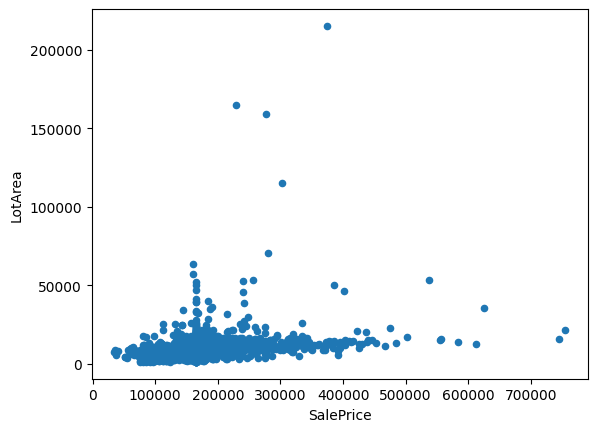

In [652]:
df.plot(x='SalePrice', y='LotArea', kind='scatter')
plt.show()

In [653]:
print(df['LotArea'].corr(df['SalePrice']))

0.246803588554617


2) Глубина (или длина) участка

In [654]:
df['LotDepth'] = df['LotArea'] / df['LotFrontage']

print(df['LotDepth'])

0       130.000000
1       120.000000
2       165.441176
3       159.166667
4       169.761905
           ...    
2914     92.190476
2915     90.190476
2916    125.000000
2917    168.403226
2918    130.094595
Name: LotDepth, Length: 2800, dtype: float64


Ну и еще немного графиков

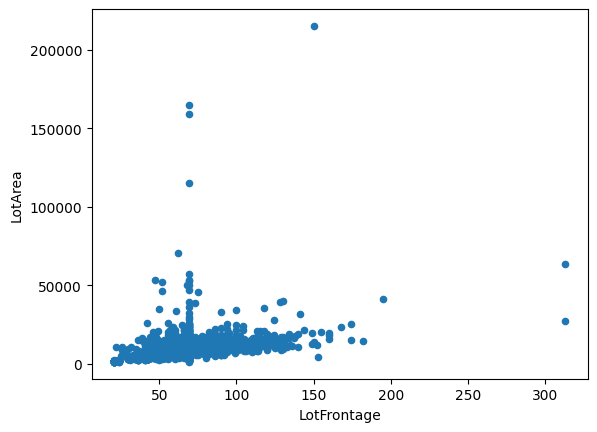

In [655]:
df.plot(x='LotFrontage', y='LotArea', kind='scatter')
plt.show()

сомнительно... но вроде кореллирует

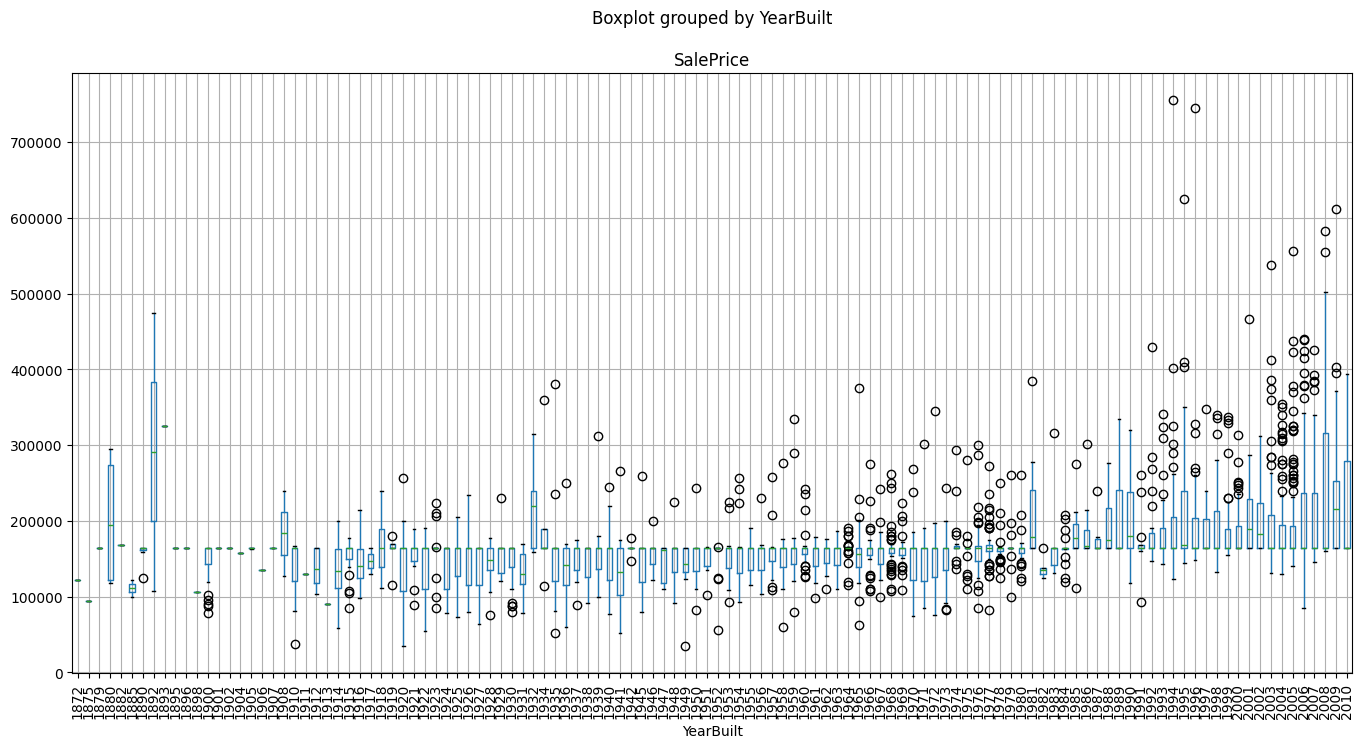

In [656]:
df.boxplot(column='SalePrice', by='YearBuilt', rot=90, figsize=(16, 8))
plt.show()

In [657]:
print(df['YearBuilt'].corr(df['SalePrice']))

0.36317165265849616


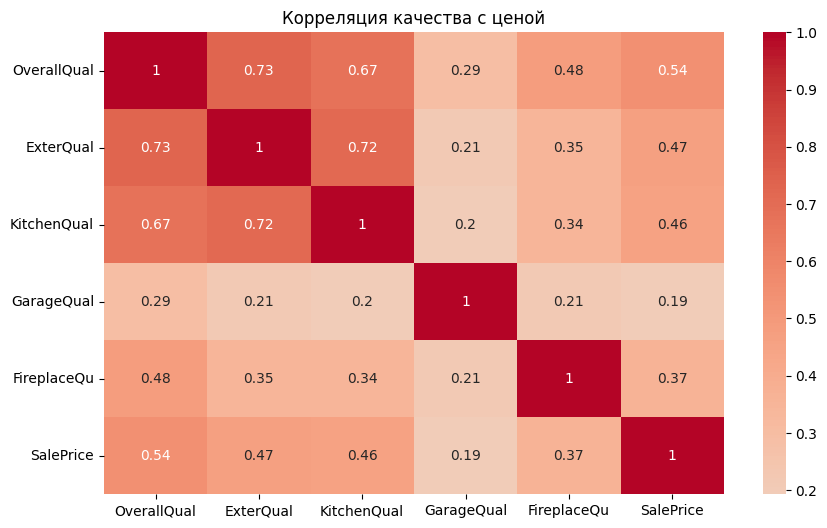

In [658]:
quality_cols = ['OverallQual', 'ExterQual', 'KitchenQual', 'GarageQual', 'FireplaceQu']
plt.figure(figsize=(10, 6))
sns.heatmap(df[quality_cols + ['SalePrice']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция качества с ценой')
plt.show()

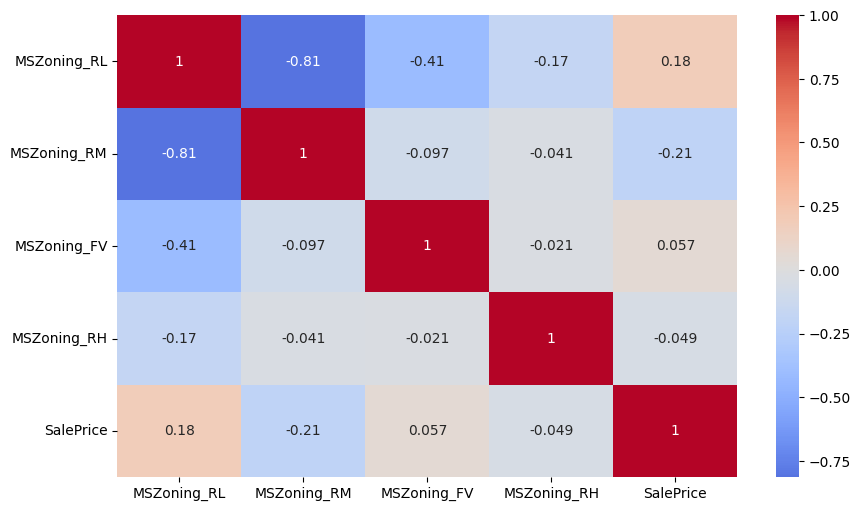

In [659]:
quality_cols = ['MSZoning_RL', 'MSZoning_RM', 'MSZoning_FV', 'MSZoning_RH']
plt.figure(figsize=(10, 6))
sns.heatmap(df[quality_cols + ['SalePrice']].corr(), annot=True, cmap='coolwarm', center=0)
plt.show()

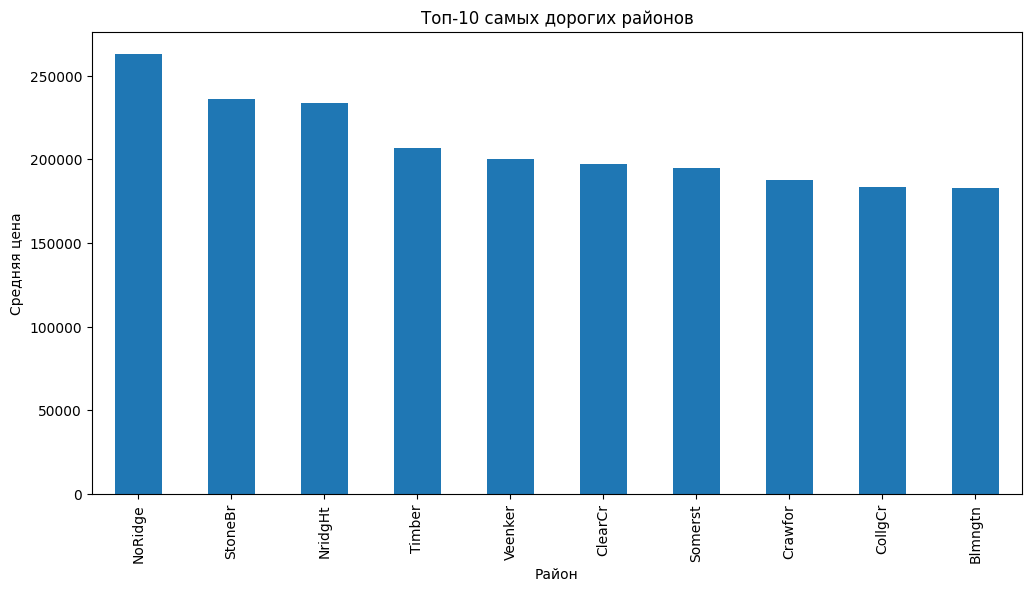

In [660]:
neighborhood_price = df.groupby(df_Neighborhood)['SalePrice'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
neighborhood_price.head(10).plot(kind='bar')
plt.title('Топ-10 самых дорогих районов')
plt.xlabel('Район')
plt.ylabel('Средняя цена')
plt.show()

In [661]:
df.info()

<class 'pandas.DataFrame'>
Index: 2800 entries, 0 to 2918
Columns: 163 entries, Id to LotDepth
dtypes: bool(92), float64(29), int64(42)
memory usage: 1.8 MB


# Итог

## Что я понял про датасет
- Датасет содержит информацию о 2919 домах в Эймсе с 81 признаком
- Если строка содержит ноль в столбцах GarageArea и GarageCars, то гаража нет.
- Нашел корреляцию между колонками GarageArea и GarageCars - 0.89, что в целом логично
- Медианное значение колонки SalePrice равно 164,6k, и что максимальная цена - 755k
- У колонки SalePrice есть положительная асимметрия и положительный эксцесс
- Многие колонки отражают качественную характеристику (с явной градацией) и к ним применим label encoding
- Корелляция между колонками LotArea и SalePrice слабая - 0.26, что подтверждает: размер участка не так важен, как качество дома
- SalePrice кореллирует с YearBuilt сильнее, чем с LotArea
- из heatmap видно, что колонки ExterQual и OverallQual имеют сильную корреляцию - 0.73, что говорит о целостности качества: хороший дом хорош во всем
- NoRidge, StoneBr, NridgHt, Timber, Veenker, ClearCr, Somerst, Crawfor, CollgCr, Blmngnt - это топ-10 самых дорогих районов 

## Гипотезы
- Гипотеза 1: Влияние зонирования на цену
  - Дома в зоне жилой низкой плотности (RL) продаются дороже домов в других зонах (корреляция +0.18), в то время как зонe средней плотности (RM) соответствуют более низкие цены (корреляция -0.21). Коммерческая зона (C) вероятно имеет еще более низкую цену, что подтверждает следующую логику: чем плотнее или более коммерческое зонирование, тем ниже стоимость жилья.

- Гипотеза 2: Влияние внешних качеств и кухни дома на цену
  - Дома с высокими внешними качествами и качественной кухней стоят дороже остальных (корреляция +0.47, +0.46 соответственно). При этом качество гаража влияет на цену намного меньше (корреляция +0.19)

- Гипотеза 3: Влияние года постройки дома на его цену
  - Исходя из полученных данных, год постройки умеренным образом влияет на цену дома (средняя корреляция +0.36)

- Гипотеза 4: Влияние площади участка на цену (опроверглась)
  - Площадь участка сильно влияет на его цену (полученная корреляция 0.25 указывает, что влияние является довольно слабым)

- Гипотеза 5: Влияние районов на цену
  - Топ-10 самых дорогих районов: NoRidge, StoneBr, NridgHt, Timber, Veenker, ClearCr, Somerst, Crawfor, CollgCr, Blmngnt. Средняя цена в этих районах выше общей медианы. Это подтверждает, что местоположение — один из ключевых факторов ценообразования

## Что бы вы сделали дальше
Далее я бы взял модель линейной регрессии и попробовал предсказать цены исходя из имеющихся обработанных данных
Или еще - разбил бы дома на дорогие и дешевые (2 варианта) и попробовал бы классифицировать дома с помощью knn

## Итого
- После обработки данных удалено 119 строк (4%), сохранено 2800 строк
- В результате Feature Engineering количество колонок увеличилось с 81 до 163
- Все пропуски обработаны, датафрейм полностью числовой

## AI в моей работе
Использовал Deepseek
Я еще ранее немного изучал pandas и сталкивался с matplotlib, так что в этой работе по большей мере все писал сам и старался вспомнить различные методы.
Применял в основном для следующего:
- Проверка оптимальности выбранного метода: я писал как знал, что хочу сделать (например сгруппировать данные), а потом спаршивал, насколько правильно сделал и как можно лучше
- Спрашивал некоторые методы, которые совсем не помнил/не знал
- Просил помощи с построениями графиков (в плане кода)
- Спрашивал про то, что такое асимметрия и эксцесс
- Сверял свои гипотезы и предположения на их верность
- Спрашивал про типы encoding'а и когда какой целесообразно применять
- Уточнял верность своих решений в плане encoding'а (уже после того, как делал)
- Спрашивал как реализовать Feature Hashing

(возможно стоило больше использовать ИИ, ибо суммарно я просидел над заданием 10.5 часов. Хотя так, за неделю, вроде больше запомнил)